# **Celestial Object Classification**

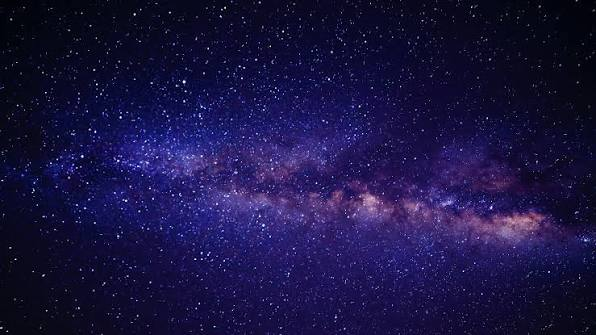

In this project, we will train machine learning models to classify celestial objects into stars, galaxies, or quasars based on their spectral data.

---

# About Dataset
The dataset contains 100,000 celestial records from the SDSS project. Each observation consists of 17 predictive/tracking metrics and 1 target label:

- obj_ID: Unique identifier for each object in the SDSS catalog.
- alpha: Right Ascension (RA) coordinate at the J2000 epoch.
- delta: Declination (Dec) coordinate at the J2000 epoch.
- u: Ultraviolet photometric magnitude.
- g: Green photometric magnitude.
- r: Red photometric magnitude.
- i: Near-infrared photometric magnitude.
- z: Infrared photometric magnitude.
- run_ID: Identifier for the SDSS imaging scan.
- rerun_ID: Identifier for the image processing version.
- cam_col: Camera column used during image acquisition.
- field_ID: Identifier for the observed sky field.
- spec_obj_ID: Unique identifier for a spectroscopic observation.
- class: Star, Galaxy, or Quasar (QSO).
- redshift: Redshift measured from spectral wavelength shift.
- plate: Spectroscopic plate identifier.
- MJD: Modified Julian Date of the observation.
- fiber_ID: Fiber identifier used for spectroscopic data collection.

**Source Attribution:**
Sourced from the public domain https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17 released by fedesoriano.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 110,
    'axes.grid':  False,
    "font.family": "DejaVu Sans"
})

PALETTE = {
    "GALAXY": "#4C72B0",
    "STAR": "#DD8452",
    "QSO": "#55A868"
}

# **Reading Dataset**

In [33]:
df = pd.read_csv("data/star_classification.csv")
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("First 5 Rows of the Dataset:")
print(df.head())

Dataset Shape: 100,000 rows × 18 columns
First 5 Rows of the Dataset:
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber

In [34]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: f

The dataset seems to be pretty clear and we do not have to deal with null values

In [38]:
print("Statistical Summary")
print(df.describe().round(2))

Statistical Summary
             obj_ID      alpha      delta          u          g          r  \
count  1.000000e+05  100000.00  100000.00  100000.00  100000.00  100000.00   
mean   1.237665e+18     177.63      24.14      21.98      20.53      19.65   
std    8.438560e+12      96.50      19.64      31.77      31.75       1.85   
min    1.237646e+18       0.01     -18.79   -9999.00   -9999.00       9.82   
25%    1.237659e+18     127.52       5.15      20.35      18.97      18.14   
50%    1.237663e+18     180.90      23.65      22.18      21.10      20.13   
75%    1.237668e+18     233.90      39.90      23.69      22.12      21.04   
max    1.237681e+18     360.00      83.00      32.78      31.60      29.57   

               i          z     run_ID  rerun_ID    cam_col   field_ID  \
count  100000.00  100000.00  100000.00  100000.0  100000.00  100000.00   
mean       19.08      18.67    4481.37     301.0       3.51     186.13   
std         1.76      31.73    1964.76       0.0       

In [39]:
print("Data Types")
print(df.dtypes)

Data Types
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object


# **Data Processing**

In [40]:
print("Missing Values:")
missing_counts = df.isnull().sum()

if missing_counts.sum() == 0:
    print("No missing values found.")
else:
    print(missing_counts)

Missing Values:
No missing values found.


In [59]:
df = df.replace(-9999, np.nan)
df = df.fillna(df.median(numeric_only=True))

# **Exploratory Data Analysis (EDA)**

Let's plot the distribution of our target variable (class) to see if the dataset is balanced.

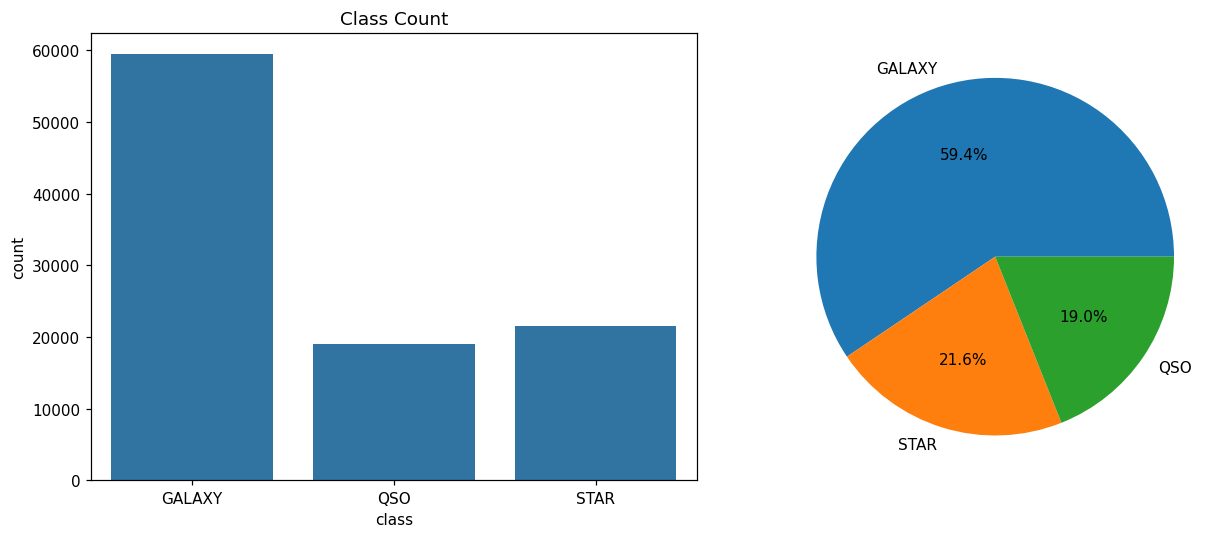

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
counts = df["class"].value_counts()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x="class")
plt.title("Class Count")

plt.subplot(1, 2, 2)
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
plt.tight_layout()
plt.show()


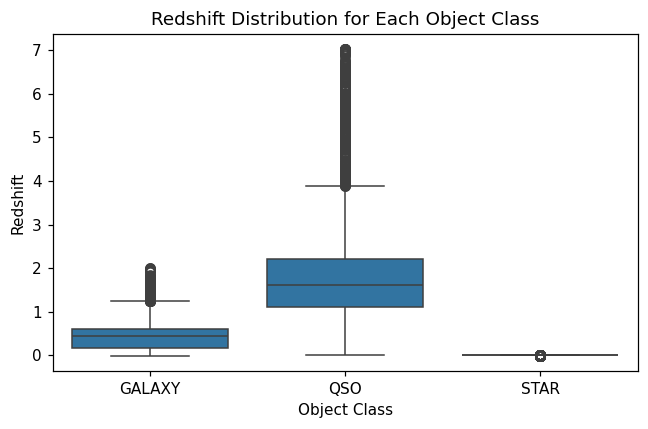

In [61]:
sns.boxplot(data=df,x="class",y="redshift")

plt.title("Redshift Distribution for Each Object Class")
plt.xlabel("Object Class")
plt.ylabel("Redshift")

plt.tight_layout()
plt.show()

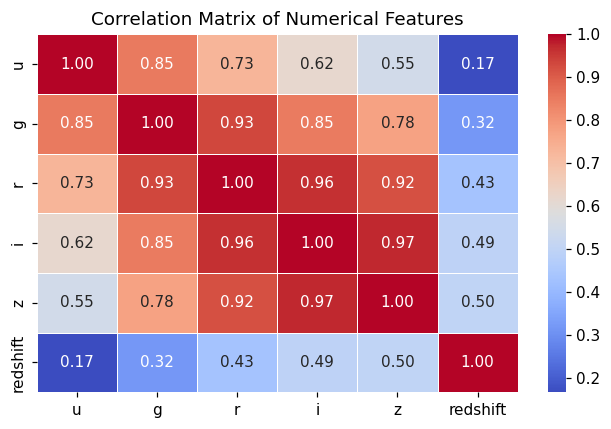

In [62]:
metadata_cols = [
    "obj_ID",
    "alpha",
    "delta",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "spec_obj_ID",
    "plate",
    "MJD",
    "fiber_ID",
    "class"
]
numeric_features = df.drop(columns=metadata_cols)

sns.heatmap(
    numeric_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# **Feature Selection**
We will select our core predictive features, encode our categorical target labels (class), and split the data into an 80/20 train-test split.

In [63]:
features = [
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
]

X = df[features]
y = df["class"]

print("Selected Features:")
print(features)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClass Encoding:")
class_names = label_encoder.classes_
for index, name in enumerate(class_names):
    print(f"{name} - {index}")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")
print(f"Number of Features: {X_train.shape[1]}")

Selected Features:
['u', 'g', 'r', 'i', 'z', 'redshift']

Class Encoding:
GALAXY - 0
QSO - 1
STAR - 2

Training Samples : 80,000
Testing Samples  : 20,000
Number of Features: 6


### Trying various classification algorithms


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained")

y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Test Accuracy: {lr_accuracy * 100:.2f}%\n")

Logistic Regression model trained
Test Accuracy: 93.72%



In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt_model.fit(X_train, y_train)
print("Decision Tree model trained")

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Test Accuracy: {dt_accuracy * 100:.2f}%\n")

Decision Tree model trained
Test Accuracy: 96.78%



In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Test Accuracy: {rf_accuracy * 100:.2f}%\n")

Random Forest model trained.
Test Accuracy: 97.98%



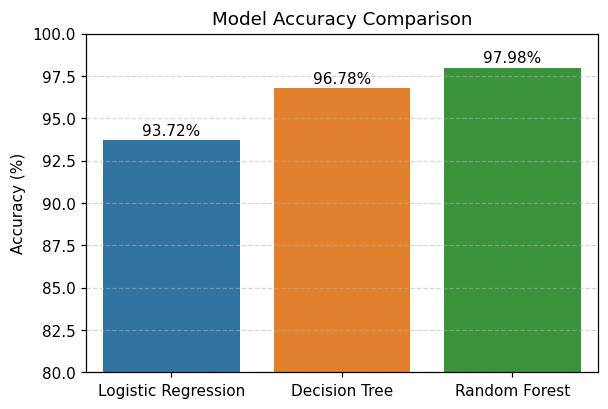

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

lr_acc = lr_accuracy * 100
dt_acc = dt_accuracy * 100
rf_acc = rf_accuracy * 100

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_acc, dt_acc, rf_acc]

ax = sns.barplot(
    x=models,
    y=accuracy,
    hue=models,
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(accuracy):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.show()

So random forest seems to be a better classifier. Now lets try tuning n_estimators

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

for n in range(10, 110, 10):
    clf = RandomForestClassifier(n_estimators=n, random_state=42, class_weight="balanced", n_jobs=-1)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)
    acc = clf.score(X_test, y_test)
    f1 = f1_score(y_test, preds, average="macro")

    print(f"n_estimators={n:3d} | Accuracy: {acc*100:.2f}% | F1 Macro: {f1:.4f}")

n_estimators= 10 | Accuracy: 97.80% | F1 Macro: 0.9742
n_estimators= 20 | Accuracy: 97.93% | F1 Macro: 0.9758
n_estimators= 30 | Accuracy: 97.97% | F1 Macro: 0.9762
n_estimators= 40 | Accuracy: 97.95% | F1 Macro: 0.9759
n_estimators= 50 | Accuracy: 97.97% | F1 Macro: 0.9762
n_estimators= 60 | Accuracy: 97.98% | F1 Macro: 0.9764
n_estimators= 70 | Accuracy: 98.00% | F1 Macro: 0.9766
n_estimators= 80 | Accuracy: 97.97% | F1 Macro: 0.9762
n_estimators= 90 | Accuracy: 98.00% | F1 Macro: 0.9765
n_estimators=100 | Accuracy: 97.98% | F1 Macro: 0.9764


Looking at the results, the model's accuracy doesn't change much across the board. However, it technically hits its peak performance when n_estimators = 90

# **Model Evaluation**

In [27]:
print("Model Performance")
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Model Performance

Test Accuracy: 97.98%

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



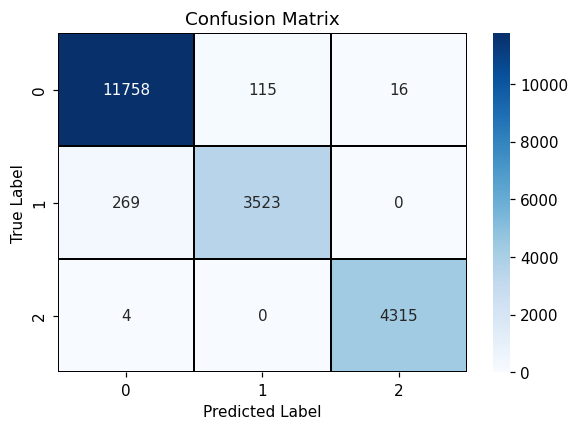

In [56]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    linewidths=1.0,
    linecolor="black",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


/tmp/ipykernel_2045/1739184100.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature", palette='rocket')


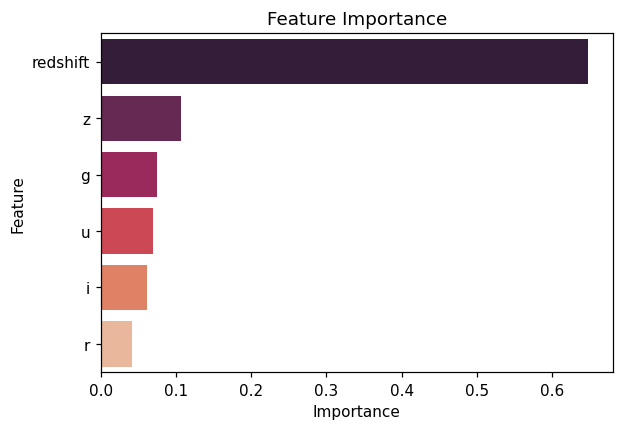

In [57]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values("Importance", ascending=False)

sns.barplot(data=feature_importance, x="Importance", y="Feature", palette='rocket')

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()